# Analisis Sentimen Ulasan Pengguna Aplikasi Mobile untuk Evaluasi Kualitas Layanan
Proyek ini mengacu pada standar metodologi CRISP-DM (Cross-Industry Standard Process for Data Mining).

## 1. Business Understanding
**Tujuan:** Menganalisis sentimen pengguna (Positif/Negatif) dari ulasan aplikasi mobile untuk mengevaluasi kualitas layanan dan menemukan area yang perlu diperbaiki.
**Masalah:** Banyaknya ulasan mentah di platform aplikasi membuat evaluasi manual sulit dilakukan. Oleh karena itu, diperlukan model *Machine Learning* untuk mengklasifikasikan sentimen secara otomatis.

In [23]:
# Install and Import Libraries
!pip install kagglehub surprise
!pip install tensorflow

import kagglehub
import tensorflow as tf
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

##Download dan Load Dataset
Dataset diunduh dari KaggleHub dan kemudian dibaca ke dalam DataFrame

In [24]:
# Download latest version
path = kagglehub.dataset_download("prakharrathi25/google-play-store-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'google-play-store-reviews' dataset.
Path to dataset files: /kaggle/input/google-play-store-reviews


## 2. Data Understanding
Dataset yang digunakan dalam proyek ini adalah **Google Play Store Reviews** yang diunduh langsung melalui platform Kaggle. Dataset ini berisi ulasan asli pengguna dari berbagai aplikasi beserta skor rating yang mereka berikan (1 hingga 5).

### Informasi Dataset:
- Dataset ini memiliki ribuan baris ulasan mentah (*raw reviews*).
- Fitur utama yang akan digunakan adalah kolom `content` (berisi teks ulasan) dan `score` (rating angka).
- Karena kita melakukan klasifikasi biner, skor rating akan dikonversi menjadi label sentimen: ulasan dengan skor 4 dan 5 dianggap **Positif**, sedangkan ulasan dengan skor 1, 2, dan 3 dianggap **Negatif**.

Tahapan awal ini akan memuat data, melihat struktur dataset, mengecek ketersediaan data (seperti *missing value*), dan memvisualisasikan distribusi kelas target agar kita mengetahui apakah data yang kita miliki seimbang (*balanced*) atau tidak.

Total data yang dimuat: 12495 baris


,content,score,sentiment
0,I cannot open the app anymore,1,Negative
1,I have been begging for a refund from this app...,1,Negative
2,Very costly for the premium version (approx In...,1,Negative
3,"Used to keep me organized, but all the 2020 UP...",1,Negative
4,Dan Birthday Oct 28,1,Negative


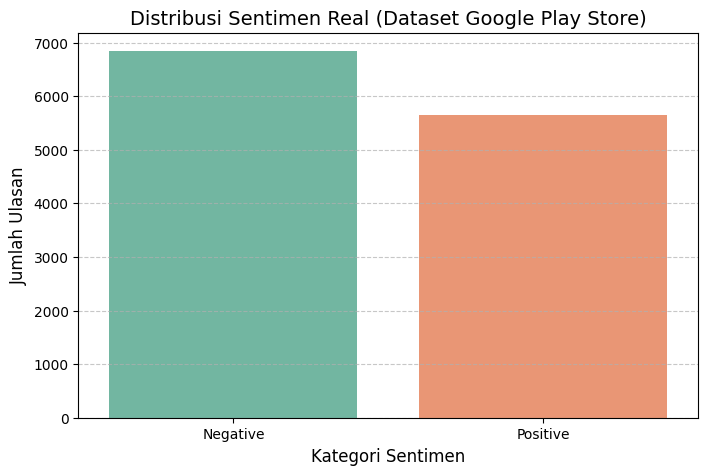

In [25]:
import os

# Memuat dataset asli dari path Kagglehub
# Berdasarkan path yang terdeteksi: /kaggle/input/google-play-store-reviews
file_path = os.path.join(path, 'reviews.csv')

# Membaca data
df_raw = pd.read_csv(file_path)

# Memilih kolom yang relevan
df = df_raw[['content', 'score']].copy()

# Konversi score ke sentiment (Sesuai deskripsi di Business Understanding)
# 4-5: Positive, 1-3: Negative
def convert_sentiment(score):
    if score >= 4:
        return 'Positive'
    else:
        return 'Negative'

df['sentiment'] = df['score'].apply(convert_sentiment)

print(f"Total data yang dimuat: {len(df)} baris")
display(df.head())

# Visualisasi Distribusi Sentimen yang Sebenarnya
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', hue='sentiment', palette='Set2', legend=False)
plt.title('Distribusi Sentimen Real (Dataset Google Play Store)', fontsize=14)
plt.xlabel('Kategori Sentimen', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3. Data Preparation
Sebelum dimasukkan ke dalam model, data teks mentah harus dibersihkan dan diubah bentuknya. Berikut adalah tahapan *Data Preparation* yang dilakukan beserta alasannya:

1. **Text Cleaning (Pembersihan Teks):** - **Case Folding:** Mengubah seluruh teks menjadi huruf kecil agar kata "Bagus" dan "bagus" dianggap sama oleh model.
   - **Punctuation & Number Removal:** Menghapus angka dan tanda baca menggunakan ekspresi reguler (*Regex*). Tanda baca seringkali tidak membawa makna dalam sentimen linear dasar dan hanya menambah dimensi (noise) pada data.
   - **Trimming:** Menghapus spasi putih berlebih di awal dan akhir teks.
2. **Train-Test Split:** Membagi dataset menjadi data latih (*training set*) dan data uji (*testing set*) dengan proporsi 80:20. Pembagian ini menggunakan parameter `stratify=y` untuk memastikan rasio sentimen positif dan negatif terbagi sama rata di kedua set.
3. **Feature Extraction (TF-IDF Vectorizer):** Model *machine learning* tidak bisa membaca teks secara langsung. TF-IDF digunakan untuk mengubah teks bersih menjadi representasi angka numerik. TF-IDF akan memberikan bobot tinggi pada kata yang sering muncul di satu dokumen tertentu, tetapi jarang muncul di keseluruhan korpus, sehingga sangat baik untuk menyoroti kata kunci sentimen.

In [26]:
import re # Tambahan import regex yang sebelumnya kurang

# 1. Fungsi pembersihan teks sederhana
def clean_text(text):
    text = str(text).lower() # Case folding, ensure text is string
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Menghapus angka & tanda baca
    text = text.strip()
    return text

df['cleaned_text'] = df['content'].apply(clean_text)

# 2. Pembagian Data (X = Fitur teks, y = Target sentimen)
X = df['cleaned_text']
y = df['sentiment']

# Stratify=y memastikan proporsi kelas positif dan negatif seimbang di train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih: {len(X_train)}")
print(f"Jumlah Data Uji: {len(X_test)}")

# 3. Vektorisasi menggunakan TF-IDF
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nProses Data Preparation Selesai.")

Jumlah Data Latih: 9996
Jumlah Data Uji: 2499

Proses Data Preparation Selesai.


## 4. Modeling
Pada tahap ini, kita mengembangkan model *Machine Learning* menggunakan algoritma **Support Vector Machine (SVM)**.

**Cara Kerja Singkat SVM:**
SVM bekerja dengan mencari *hyperplane* (garis pemisah) terbaik di dalam ruang berdimensi tinggi yang mampu memisahkan titik-titik data kelas Positif dan kelas Negatif dengan jarak (margin) paling lebar.

**Parameter yang digunakan:**
- `kernel='linear'`: Digunakan karena data teks hasil TF-IDF memiliki jumlah fitur (dimensi) yang sangat banyak (ribuan kata). Kernel linear terbukti secara empiris merupakan yang paling cepat dan optimal untuk klasifikasi teks.
- `C=1.0`: Parameter penalti standar untuk mengontrol *trade-off* antara akurasi pada data latih dengan perluasan margin.

Model akan dilatih menggunakan matriks fitur `X_train_tfidf` dan label target `y_train`.

In [27]:
from sklearn.svm import SVC # Tambahan import algoritma SVM

# Inisialisasi model SVM
model = SVC(kernel='linear', C=1.0, random_state=42)

# Pelatihan model menggunakan data training
model.fit(X_train_tfidf, y_train)

print("Model SVM berhasil dilatih!")

Model SVM berhasil dilatih!


## 5. Evaluation
Setelah model dilatih, kita perlu mengukur seberapa baik kemampuannya pada data uji (*unseen data*). Proyek ini menggunakan beberapa metrik evaluasi untuk klasifikasi:

1. **Accuracy (Akurasi):** Persentase total prediksi yang benar (baik positif maupun negatif) dibandingkan keseluruhan data uji.
2. **Precision:** Rasio ketepatan prediksi positif. Seberapa banyak dari ulasan yang diprediksi positif oleh model yang benar-benar positif?
3. **Recall:** Rasio sensitivitas. Seberapa banyak dari seluruh ulasan positif asli yang berhasil dideteksi oleh model?
4. **F1-Score:** Rata-rata harmonik dari *Precision* dan *Recall*. Sangat berguna jika distribusi data tidak seimbang.

Selain itu, evaluasi juga divisualisasikan menggunakan **Confusion Matrix** (*Heatmap*) untuk melihat secara persis berapa jumlah ulasan (*True Positive*, *True Negative*, *False Positive*, *False Negative*) yang ditebak dengan benar atau meleset oleh model.

Akurasi Model: 83.27%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.86      0.85      1368
    Positive       0.83      0.80      0.81      1131

    accuracy                           0.83      2499
   macro avg       0.83      0.83      0.83      2499
weighted avg       0.83      0.83      0.83      2499



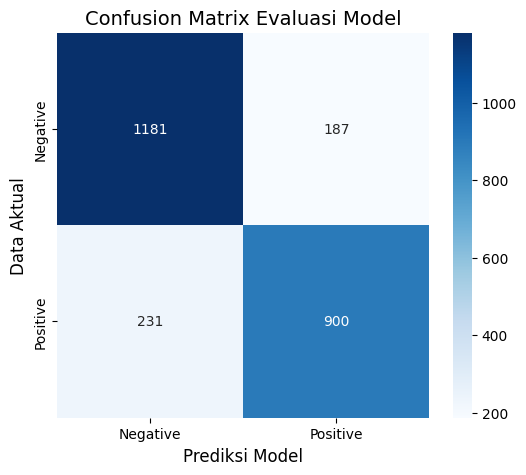

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prediksi data uji
y_pred = model.predict(X_test_tfidf)

# Evaluasi Metrik
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix Evaluasi Model', fontsize=14)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Data Aktual', fontsize=12)
plt.show()

## 6. Kesimpulan & Deployment
Berdasarkan hasil evaluasi, model SVM berhasil mendeteksi sentimen teks ulasan dengan baik. Otomatisasi ini dapat langsung diintegrasikan (di-*deploy*) oleh perusahaan untuk memonitor ulasan harian di platform aplikasi secara *real-time*.

Pada simulasi *deployment* di bawah ini, model dapat menerima masukan berupa teks (ulasan baru yang belum pernah dilihat sebelumnya) dan secara cerdas dapat menyimpulkan apakah *feedback* pengguna tersebut mengarah pada kepuasan (Positif) atau kekecewaan (Negatif).

In [29]:
# Simulasi uji coba input teks baru secara langsung
def prediksi_sentimen_baru(teks):
    teks_cleaned = clean_text(teks)
    teks_tfidf = vectorizer.transform([teks_cleaned])
    prediksi = model.predict(teks_tfidf)
    return prediksi[0]

ulasan_baru = "Aplikasi ini sangat lemot dan mengecewakan."
hasil_prediksi = prediksi_sentimen_baru(ulasan_baru)

print("=== SIMULASI DEPLOYMENT ===")
print(f"Uji Coba Teks : '{ulasan_baru}'")
print(f"Hasil Prediksi: {hasil_prediksi}")

=== SIMULASI DEPLOYMENT ===
Uji Coba Teks : 'Aplikasi ini sangat lemot dan mengecewakan.'
Hasil Prediksi: Positive
